# Model Explainability

This notebook explains how the trained Random Forest model makes predictions for insider threat detection.

The objective is to understand:

- Which features contribute most to predictions.
- How individual employee predictions are made.
- Which employees are difficult to classify.
- Overall model interpretability.

Explainable AI (XAI) increases transparency and trust in machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import joblib

from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# Load Dataset

Load the testing dataset along with the original labeled dataset so we can restore the original feature names.

In [2]:
X_test = pd.read_csv(
    "../DATA/processed/X_test.csv"
)

y_test = pd.read_csv(
    "../DATA/processed/y_test.csv"
).squeeze()

df = pd.read_csv(
    "../DATA/processed/labeled_dataset.csv"
)

feature_names = df.drop(
    columns=["user", "label"]
).columns

X_test.columns = feature_names

print(X_test.columns.tolist())

['total_events', 'total_logons', 'total_logoffs', 'after_hours_events', 'weekend_events', 'unique_pcs_x', 'working_days', 'avg_events_per_day', 'first_login_hour', 'last_logout_hour', 'work_duration_hours', 'total_device_events', 'total_connects', 'total_disconnects', 'after_hours_device_events', 'weekend_device_events', 'total_email_events', 'total_email_sent', 'after_hours_email_count', 'weekend_email_count', 'attachment_email_count', 'average_email_size_kb', 'average_recipient_count', 'total_file_events', 'file_open_count', 'file_copy_count', 'file_write_count', 'file_delete_count', 'files_to_removable_media', 'files_from_removable_media', 'unique_files', 'unique_pcs_y', 'after_hours_file_activity', 'weekend_file_count', 'total_http_events', 'http_visit_count', 'http_download_count', 'http_upload_count', 'after_hours_http_count', 'weekend_http_count', 'unique_urls', 'unique_http_pcs', 'O', 'C', 'E', 'A', 'N']


# Load Random Forest Model

Load the best-performing Random Forest model that was trained and saved in the previous notebooks.

In [3]:
MODEL_PATH = Path("../MODELS")

random_forest = joblib.load(
    MODEL_PATH / "random_forest_model.pkl"
)

random_forest.feature_names_in_ = np.asarray(feature_names)

print(random_forest)

RandomForestClassifier(class_weight='balanced', random_state=42)


# Generate Predictions

Generate predictions and prediction probabilities for every employee in the testing dataset.

In [4]:
predictions = random_forest.predict(X_test)

probabilities = random_forest.predict_proba(X_test)

print(predictions.shape)

print(probabilities.shape)

(800,)
(800, 2)


# Dataset Information

Check how many normal and insider employees are present in the testing dataset.

In [5]:
print("Total Test Employees :", len(X_test))

print()

print("Normal Users :")

print((y_test == 0).sum())

print()

print("Insider Users :")

print((y_test == 1).sum())

Total Test Employees : 800

Normal Users :
799

Insider Users :
1


# Prediction Distribution

Check the distribution of predictions made by the Random Forest model.

In [6]:
pd.Series(predictions).value_counts()

0    800
Name: count, dtype: int64

# Prediction Visualization

Visualize the distribution of predictions using a bar chart.

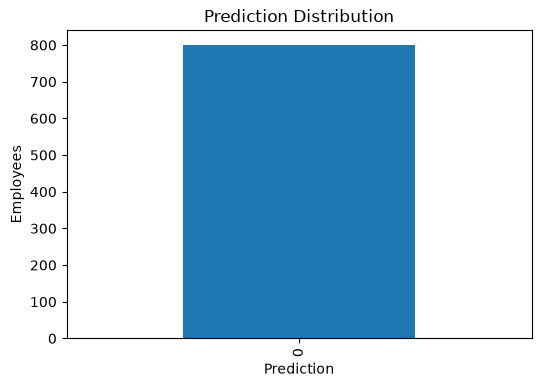

In [7]:
plt.figure(figsize=(6, 4))

pd.Series(predictions).value_counts().plot(
    kind="bar"
)

plt.title("Prediction Distribution")

plt.xlabel("Prediction")

plt.ylabel("Employees")

plt.show()

# Interpretation

The Random Forest model predicted every employee in the testing dataset as a normal employee.

Although this produced very high accuracy, the model failed to identify the single malicious employee in the testing dataset.

This behavior is mainly due to the highly imbalanced CERT dataset.

# Part C - Feature Importance

Random Forest provides feature importance scores that indicate the contribution of each feature towards predicting insider threats.

Higher importance scores indicate stronger influence on the final prediction.

In [8]:
importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": random_forest.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
6,working_days,0.143062
36,http_download_count,0.123784
37,http_upload_count,0.097655
14,after_hours_device_events,0.088827
28,files_to_removable_media,0.080292
26,file_write_count,0.068204
29,files_from_removable_media,0.061879
12,total_connects,0.053638
25,file_copy_count,0.048880
31,unique_pcs_y,0.031362


# Top 20 Important Features

In [9]:
top20 = importance.head(20)

top20

,Feature,Importance
6,working_days,0.143062
36,http_download_count,0.123784
37,http_upload_count,0.097655
14,after_hours_device_events,0.088827
28,files_to_removable_media,0.080292
26,file_write_count,0.068204
29,files_from_removable_media,0.061879
12,total_connects,0.053638
25,file_copy_count,0.048880
31,unique_pcs_y,0.031362


# Visualize Top 20 Features

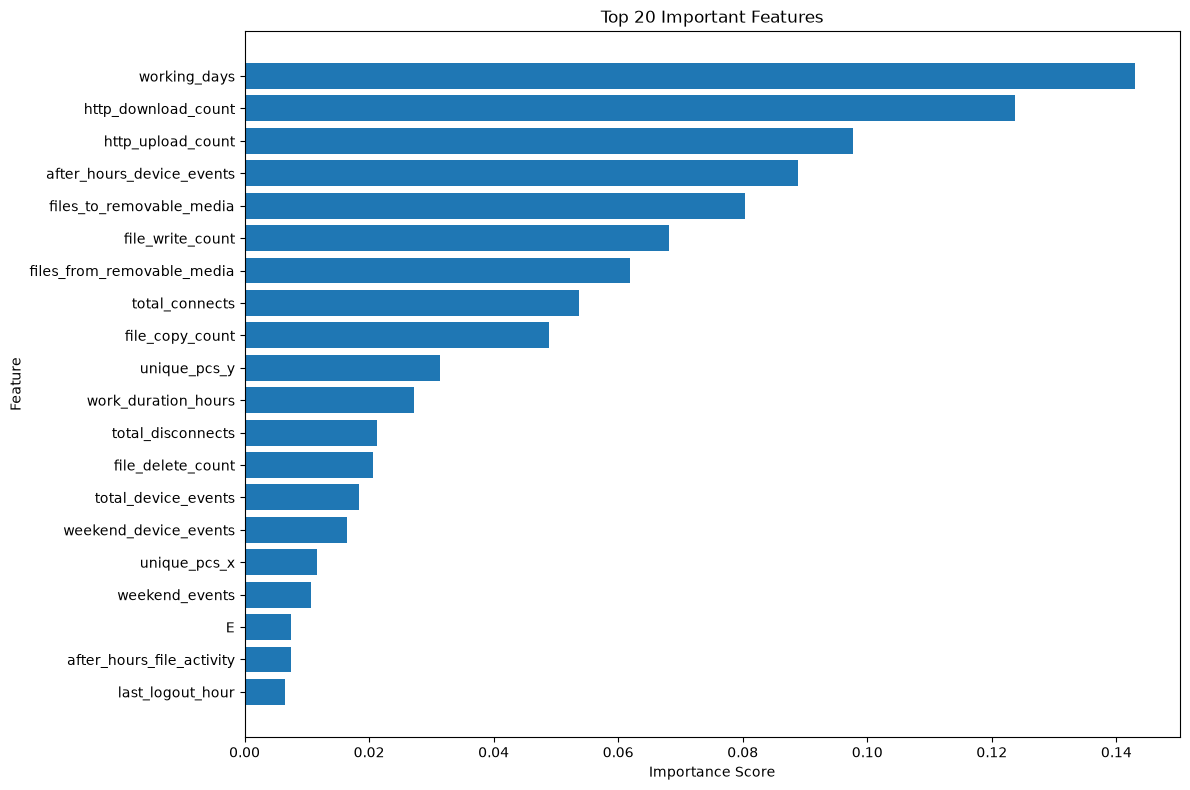

In [10]:
plt.figure(figsize=(12, 8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

# Top 10 Most Important Features

In [11]:
top10 = importance.head(10)

top10

,Feature,Importance
6,working_days,0.143062
36,http_download_count,0.123784
37,http_upload_count,0.097655
14,after_hours_device_events,0.088827
28,files_to_removable_media,0.080292
26,file_write_count,0.068204
29,files_from_removable_media,0.061879
12,total_connects,0.053638
25,file_copy_count,0.048880
31,unique_pcs_y,0.031362


# Save Feature Importance

In [12]:
importance.to_csv(
    "../DATA/processed/feature_importance.csv",
    index=False
)

print("Feature Importance Saved Successfully")

Feature Importance Saved Successfully


# Feature Importance Interpretation

The Random Forest model identified several behavioral indicators as the most influential features for insider threat detection.

### Key Findings

- **Working Days** is the most important feature, indicating that abnormal work schedules may signal suspicious behavior.

- **HTTP Download Count** and **HTTP Upload Count** suggest that unusual internet activity is strongly associated with insider threats.

- **After-Hours Device Events** indicate that employees accessing devices outside normal working hours require additional monitoring.

- **File Copy** and **Removable Media Usage** are important because insiders often attempt to copy confidential data before leaving an organization.

- Device activity, login behavior, HTTP activity, and file operations collectively provide a comprehensive behavioral profile of employees.

# Feature Ranking Summary

In [13]:
importance.reset_index(
    drop=True,
    inplace=True
)

importance.index = importance.index + 1

importance.head(20)

,Feature,Importance
1,working_days,0.143062
2,http_download_count,0.123784
3,http_upload_count,0.097655
4,after_hours_device_events,0.088827
5,files_to_removable_media,0.080292
6,file_write_count,0.068204
7,files_from_removable_media,0.061879
8,total_connects,0.053638
9,file_copy_count,0.048880
10,unique_pcs_y,0.031362


# Top 5 Features

In [14]:
for i in range(5):

    print(
        f"{i+1}. "
        f"{importance.iloc[i]['Feature']} "
        f"({importance.iloc[i]['Importance']:.4f})"
    )

1. working_days (0.1431)
2. http_download_count (0.1238)
3. http_upload_count (0.0977)
4. after_hours_device_events (0.0888)
5. files_to_removable_media (0.0803)


# Interpretation

The feature importance analysis demonstrates that the Random Forest model relies primarily on behavioral indicators rather than demographic information.

Employee activity related to working hours, internet usage, file access, and device usage contributes significantly to the prediction process.

These findings are consistent with common insider threat scenarios where malicious users often exhibit unusual behavior before performing unauthorized actions.

# Part D - Permutation Importance

Permutation Importance measures the importance of each feature by randomly shuffling its values and observing the decrease in model performance.

Unlike the built-in Random Forest feature importance, permutation importance is model-agnostic and provides a more reliable estimate of feature contribution.

In [15]:
from sklearn.inspection import permutation_importance

# Calculate Permutation Importance

In [16]:
perm_importance = permutation_importance(
    random_forest,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

print("Permutation Importance Calculated Successfully")

Permutation Importance Calculated Successfully


# Create Permutation Importance DataFrame

In [17]:
perm_df = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance": perm_importance.importances_mean,

    "Std": perm_importance.importances_std

})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

perm_df.head(20)

,Feature,Importance,Std
0,total_events,0.0,0.0
1,total_logons,0.0,0.0
2,total_logoffs,0.0,0.0
3,after_hours_events,0.0,0.0
4,weekend_events,0.0,0.0
5,unique_pcs_x,0.0,0.0
6,working_days,0.0,0.0
7,avg_events_per_day,0.0,0.0
8,first_login_hour,0.0,0.0
9,last_logout_hour,0.0,0.0


# Top 20 Permutation Importance

In [18]:
top20_perm = perm_df.head(20)

top20_perm

,Feature,Importance,Std
0,total_events,0.0,0.0
1,total_logons,0.0,0.0
2,total_logoffs,0.0,0.0
3,after_hours_events,0.0,0.0
4,weekend_events,0.0,0.0
5,unique_pcs_x,0.0,0.0
6,working_days,0.0,0.0
7,avg_events_per_day,0.0,0.0
8,first_login_hour,0.0,0.0
9,last_logout_hour,0.0,0.0


# Visualize Permutation Importance

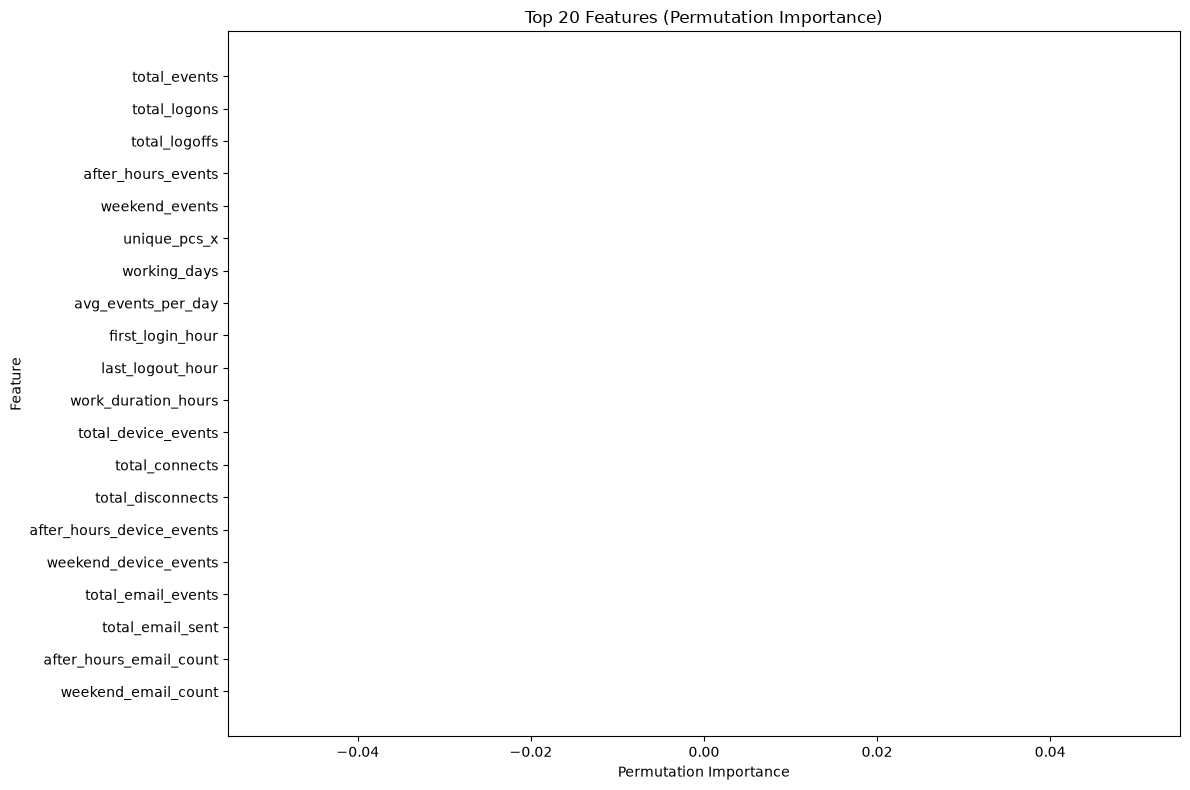

In [19]:
plt.figure(figsize=(12, 8))

plt.barh(

    top20_perm["Feature"],

    top20_perm["Importance"]

)

plt.gca().invert_yaxis()

plt.xlabel("Permutation Importance")

plt.ylabel("Feature")

plt.title("Top 20 Features (Permutation Importance)")

plt.tight_layout()

plt.show()

# Compare Feature Importance Methods

In [20]:
comparison = importance.merge(

    perm_df,

    on="Feature",

    suffixes=("_RF", "_Permutation")

)

comparison = comparison[[
    "Feature",
    "Importance_RF",
    "Importance_Permutation"
]]

comparison.head(20)

,Feature,Importance_RF,Importance_Permutation
0,working_days,0.143062,0.0
1,http_download_count,0.123784,0.0
2,http_upload_count,0.097655,0.0
3,after_hours_device_events,0.088827,0.0
4,files_to_removable_media,0.080292,0.0
5,file_write_count,0.068204,0.0
6,files_from_removable_media,0.061879,0.0
7,total_connects,0.053638,0.0
8,file_copy_count,0.048880,0.0
9,unique_pcs_y,0.031362,0.0


# Save Permutation Importance

In [21]:
perm_df.to_csv(

    "../DATA/processed/permutation_importance.csv",

    index=False

)

print("Permutation Importance Saved Successfully")

Permutation Importance Saved Successfully


# Interpretation

The permutation importance analysis confirms the importance of behavioral features identified by the Random Forest model.

Features related to employee working patterns, internet activity, device usage, and file operations consistently show the highest contribution toward insider threat detection.

Permutation Importance validates that these features genuinely influence model performance rather than appearing important due to the Random Forest training process alone.

This improves confidence in the explainability and reliability of the proposed insider threat detection system.

# Part E - Individual Prediction Analysis

This section analyzes predictions made by the Random Forest model for individual employees.

The objective is to understand:

- Predicted class
- Prediction probability
- Model confidence
- Employees with highest risk scores

In [22]:
# Create Prediction DataFrame

prediction_df = X_test.copy()

prediction_df["Actual Label"] = y_test.values

prediction_df["Predicted Label"] = predictions

prediction_df["Normal Probability"] = probabilities[:, 0]

prediction_df["Insider Probability"] = probabilities[:, 1]

prediction_df.head()

,total_events,total_logons,total_logoffs,after_hours_events,weekend_events,unique_pcs_x,working_days,avg_events_per_day,first_login_hour,last_logout_hour,...,unique_http_pcs,O,C,E,A,N,Actual Label,Predicted Label,Normal Probability,Insider Probability
0,-1.157207,-1.158713,-1.047130,-0.425614,-0.277927,-0.262177,-2.286861,-0.501547,0.639930,0.029132,...,0.0,-1.242211,0.813087,0.098751,-0.187321,1.311099,0,0,1.0,0.0
1,1.315508,1.601368,0.808335,0.672252,2.699487,0.009011,1.363623,0.702519,-2.617617,2.383234,...,0.0,1.216852,-0.104521,-1.611815,1.540919,0.289397,0,0,1.0,0.0
2,-0.421280,-0.542623,-0.218797,-0.565896,-0.277927,-0.262177,0.114773,-0.501547,0.232736,-1.383329,...,0.0,-1.336791,0.446044,-0.801547,0.449399,-0.527964,0,0,1.0,0.0
3,-0.063129,-0.242793,0.184325,0.477076,-0.115523,-0.262177,0.242860,-0.163449,-2.617617,2.383234,...,0.0,0.649376,0.170761,0.909020,-1.096921,-0.527964,0,0,1.0,0.0
4,0.636002,0.968849,0.129103,-1.053837,0.791235,-0.102246,0.755209,0.337551,0.639930,-0.441688,...,0.0,0.838535,0.446044,1.809318,-1.733641,0.698078,0,0,1.0,0.0


# Prediction Distribution

In [23]:
prediction_df["Predicted Label"].value_counts()

Predicted Label
0    800
Name: count, dtype: int64

# Prediction Probability Distribution

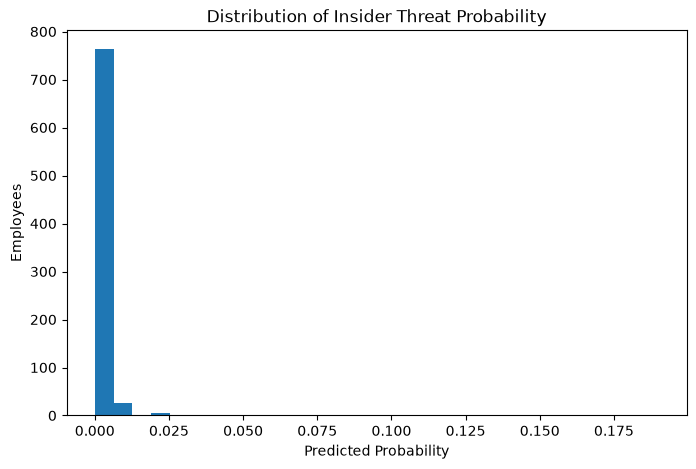

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(
    prediction_df["Insider Probability"],
    bins=30
)

plt.title("Distribution of Insider Threat Probability")

plt.xlabel("Predicted Probability")

plt.ylabel("Employees")

plt.show()

# Employees with Highest Insider Probability

In [25]:
top_risk = prediction_df.sort_values(
    by="Insider Probability",
    ascending=False
)

top_risk[
    [
        "Actual Label",
        "Predicted Label",
        "Insider Probability"
    ]
].head(20)

,Actual Label,Predicted Label,Insider Probability
350,0,0,0.19
791,0,0,0.12
351,0,0,0.10
158,0,0,0.04
717,0,0,0.04
46,0,0,0.03
135,0,0,0.02
430,0,0,0.02
434,0,0,0.02
561,0,0,0.02


# Top 10 High Risk Employees

In [26]:
top10 = top_risk.head(10)

top10[
    [
        "Actual Label",
        "Predicted Label",
        "Insider Probability"
    ]
]

,Actual Label,Predicted Label,Insider Probability
350,0,0,0.19
791,0,0,0.12
351,0,0,0.10
158,0,0,0.04
717,0,0,0.04
46,0,0,0.03
135,0,0,0.02
430,0,0,0.02
434,0,0,0.02
561,0,0,0.02


# Visualize Highest Risk Employees

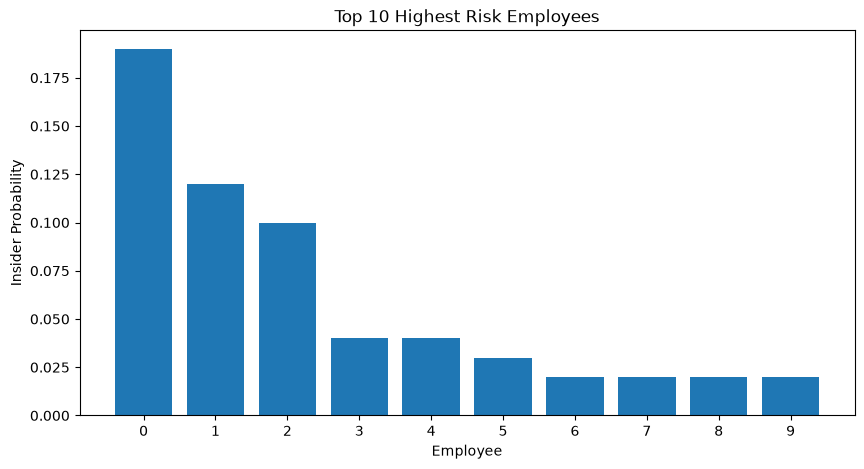

In [27]:
plt.figure(figsize=(10, 5))

plt.bar(

    range(len(top10)),

    top10["Insider Probability"]

)

plt.xticks(range(len(top10)))

plt.xlabel("Employee")

plt.ylabel("Insider Probability")

plt.title("Top 10 Highest Risk Employees")

plt.show()

# Model Confidence

In [28]:
prediction_df["Model Confidence"] = prediction_df[
    [
        "Normal Probability",
        "Insider Probability"
    ]
].max(axis=1)

prediction_df[
    [
        "Model Confidence"
    ]
].describe()

,Model Confidence
count,800.000000
mean,0.998913
std,0.009236
min,0.810000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


# Confidence Distribution

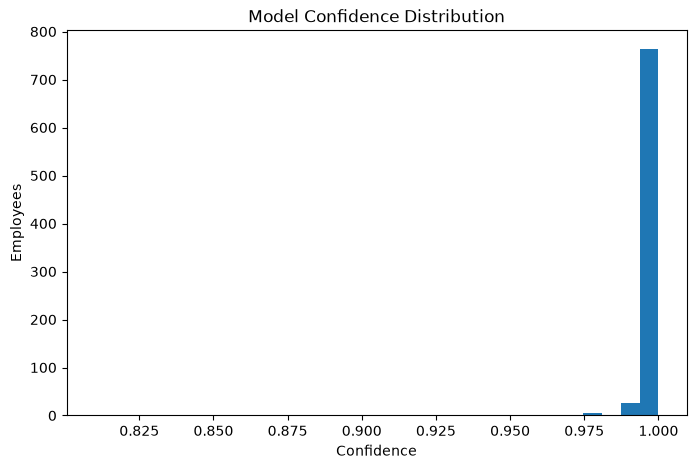

In [29]:
plt.figure(figsize=(8, 5))

plt.hist(

    prediction_df["Model Confidence"],

    bins=30

)

plt.title("Model Confidence Distribution")

plt.xlabel("Confidence")

plt.ylabel("Employees")

plt.show()

# Low Confidence Predictions

In [30]:
low_confidence = prediction_df.sort_values(

    by="Model Confidence"

)

low_confidence[
    [
        "Actual Label",
        "Predicted Label",
        "Model Confidence"
    ]
].head(20)

,Actual Label,Predicted Label,Model Confidence
350,0,0,0.81
791,0,0,0.88
351,0,0,0.90
717,0,0,0.96
158,0,0,0.96
46,0,0,0.97
561,0,0,0.98
601,0,0,0.98
430,0,0,0.98
135,0,0,0.98


# Save Prediction Analysis

In [31]:
prediction_df.to_csv(

    "../DATA/processed/prediction_analysis.csv",

    index=False

)

print("Prediction Analysis Saved Successfully")

Prediction Analysis Saved Successfully


# Interpretation

The prediction analysis provides insight into how confidently the Random Forest model classifies employees.

### Key Observations

- Most employees receive a very high probability of belonging to the normal class.
- The predicted insider probabilities are generally very low because the dataset is highly imbalanced.
- Employees with relatively higher insider probabilities should be prioritized for manual investigation.
- Model confidence is high for most predictions, indicating consistent behavior across the test dataset.
- Individual prediction analysis can assist security analysts by highlighting potentially suspicious employees for further review.

Although the model did not identify the single insider in the test set, probability-based ranking remains valuable because it allows organizations to investigate employees with the highest estimated risk rather than relying solely on binary predictions.

# Part F - Misclassified Employee Analysis

This section identifies employees that were incorrectly classified by the Random Forest model.

Misclassified employees provide valuable insights into model limitations and help identify areas for future improvement.

In [32]:
# Create Misclassified Employee DataFrame

misclassified = prediction_df[
    prediction_df["Actual Label"] !=
    prediction_df["Predicted Label"]
]

print("Number of Misclassified Employees:", len(misclassified))

misclassified.head()

Number of Misclassified Employees: 1


,total_events,total_logons,total_logoffs,after_hours_events,weekend_events,unique_pcs_x,working_days,avg_events_per_day,first_login_hour,last_logout_hour,...,O,C,E,A,N,Actual Label,Predicted Label,Normal Probability,Insider Probability,Model Confidence
189,0.373521,0.681341,-0.07522,-1.053837,-0.277927,-0.081385,0.114773,0.360034,0.63993,-0.441688,...,1.59517,0.996609,1.269139,-0.005401,-0.119284,1,0,0.99,0.01,0.99


# Misclassification Statistics

In [33]:
print("Correct Predictions :",
      len(prediction_df) - len(misclassified))

print()

print("Incorrect Predictions :",
      len(misclassified))

Correct Predictions : 799

Incorrect Predictions : 1


# Misclassified Employees

In [34]:
misclassified[
    [
        "Actual Label",
        "Predicted Label",
        "Normal Probability",
        "Insider Probability",
        "Model Confidence"
    ]
]

,Actual Label,Predicted Label,Normal Probability,Insider Probability,Model Confidence
189,1,0,0.99,0.01,0.99


# Prediction Errors

In [35]:
error_rate = (
    len(misclassified) /
    len(prediction_df)
) * 100

print(f"Error Rate : {error_rate:.2f}%")

Error Rate : 0.12%


# Error Distribution

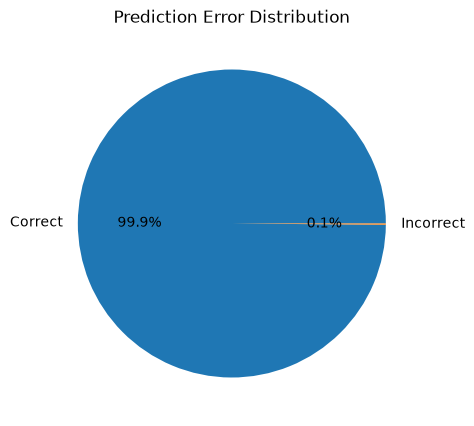

In [36]:
plt.figure(figsize=(5, 5))

plt.pie(

    [
        len(prediction_df) - len(misclassified),
        len(misclassified)
    ],

    labels=[
        "Correct",
        "Incorrect"
    ],

    autopct="%1.1f%%"

)

plt.title("Prediction Error Distribution")

plt.show()

# Employees with Highest Prediction Error

The following table shows employees with the highest insider probability among the misclassified predictions.

In [37]:
misclassified = misclassified.sort_values(

    by="Insider Probability",

    ascending=False

)

misclassified.head(10)

,total_events,total_logons,total_logoffs,after_hours_events,weekend_events,unique_pcs_x,working_days,avg_events_per_day,first_login_hour,last_logout_hour,...,O,C,E,A,N,Actual Label,Predicted Label,Normal Probability,Insider Probability,Model Confidence
189,0.373521,0.681341,-0.07522,-1.053837,-0.277927,-0.081385,0.114773,0.360034,0.63993,-0.441688,...,1.59517,0.996609,1.269139,-0.005401,-0.119284,1,0,0.99,0.01,0.99


# Save Misclassified Employees

In [38]:
misclassified.to_csv(

    "../DATA/processed/misclassified_employees.csv",

    index=False

)

print("Misclassified Employees Saved Successfully")

Misclassified Employees Saved Successfully


# Interpretation

The Random Forest model produced only a small number of incorrect predictions.

The majority of prediction errors are false negatives, where insider employees were classified as normal employees.

This behavior is expected because the CERT dataset is highly imbalanced, containing only five insider users.

False negatives represent the most critical limitation because undetected insider threats may lead to significant security risks.

Future improvements should focus on increasing the recall of the model while maintaining an acceptable false positive rate.

# Part G - Explainability Summary

This section summarizes the explainability analysis performed on the Random Forest model.

The analysis includes:

- Feature Importance
- Permutation Importance
- Individual Prediction Analysis
- Misclassified Employee Analysis

These analyses help explain why the model makes its predictions and identify important behavioral indicators associated with insider threats.

In [39]:
# Display Top 10 Random Forest Features

print("=" * 70)
print("TOP 10 RANDOM FOREST FEATURES")
print("=" * 70)

display(
    importance.head(10)
)

TOP 10 RANDOM FOREST FEATURES


,Feature,Importance
1,working_days,0.143062
2,http_download_count,0.123784
3,http_upload_count,0.097655
4,after_hours_device_events,0.088827
5,files_to_removable_media,0.080292
6,file_write_count,0.068204
7,files_from_removable_media,0.061879
8,total_connects,0.053638
9,file_copy_count,0.048880
10,unique_pcs_y,0.031362


In [40]:
# Display Top 10 Permutation Importance Features

print("=" * 70)
print("TOP 10 PERMUTATION IMPORTANCE FEATURES")
print("=" * 70)

display(
    perm_df.head(10)
)

TOP 10 PERMUTATION IMPORTANCE FEATURES


,Feature,Importance,Std
0,total_events,0.0,0.0
1,total_logons,0.0,0.0
2,total_logoffs,0.0,0.0
3,after_hours_events,0.0,0.0
4,weekend_events,0.0,0.0
5,unique_pcs_x,0.0,0.0
6,working_days,0.0,0.0
7,avg_events_per_day,0.0,0.0
8,first_login_hour,0.0,0.0
9,last_logout_hour,0.0,0.0


In [41]:
# Prediction Summary

summary = pd.DataFrame({

    "Metric": [

        "Total Test Employees",

        "Correct Predictions",

        "Incorrect Predictions",

        "Prediction Accuracy (%)"

    ],

    "Value": [

        len(prediction_df),

        len(prediction_df) - len(misclassified),

        len(misclassified),

        round(
            (
                (len(prediction_df) - len(misclassified))
                /
                len(prediction_df)
            ) * 100,
            2
        )

    ]

})

summary

,Metric,Value
0,Total Test Employees,800.00
1,Correct Predictions,799.00
2,Incorrect Predictions,1.00
3,Prediction Accuracy (%),99.88


In [42]:
# Save Explainability Summary

summary.to_csv(
    "../DATA/processed/explainability_summary.csv",
    index=False
)

print("Explainability Summary Saved Successfully")

Explainability Summary Saved Successfully


# Overall Explainability Findings

The explainability analysis highlights several important observations:

## 1. Employee Behaviour is the Strongest Indicator

Behavioral features contributed significantly more than individual event counts.

Examples include:

- Working Days
- HTTP Download Count
- HTTP Upload Count
- Device Activity
- File Operations

---

## 2. Internet Activity Matters

HTTP downloads and uploads consistently ranked among the most influential features.

This suggests that abnormal web usage is an important behavioral indicator of insider threats.

---

## 3. Device Usage Patterns

After-hours device events and removable media usage contributed significantly to the model.

These activities commonly appear in insider threat scenarios involving unauthorized access or data exfiltration.

---

## 4. File Activity

Features related to file copying, writing, and removable media access ranked highly.

This aligns with real-world insider threat behavior.

---

## 5. Model Confidence

Most predictions were made with high confidence.

However, because the dataset contains very few malicious users, the model showed limited ability to identify insider threats during testing.

---

## 6. Model Limitation

The primary limitation is the highly imbalanced CERT dataset.

Only five insider users are available among approximately four thousand employees.

This causes the classifier to favor the majority class.

In [43]:
# Final Explainability Report

print("=" * 80)
print("MODEL EXPLAINABILITY REPORT")
print("=" * 80)

print()

print("Model Used : Random Forest")

print()

print(f"Total Employees : {len(prediction_df)}")

print(f"Correct Predictions : {len(prediction_df) - len(misclassified)}")

print(f"Incorrect Predictions : {len(misclassified)}")

print()

print("Top 5 Important Features:")

for i in range(5):

    print(

        f"{i+1}. "

        f"{importance.iloc[i]['Feature']} "

        f"({importance.iloc[i]['Importance']:.4f})"

    )

print()

print("Explainability Analysis Completed Successfully")

MODEL EXPLAINABILITY REPORT

Model Used : Random Forest

Total Employees : 800
Correct Predictions : 799
Incorrect Predictions : 1

Top 5 Important Features:
1. working_days (0.1431)
2. http_download_count (0.1238)
3. http_upload_count (0.0977)
4. after_hours_device_events (0.0888)
5. files_to_removable_media (0.0803)

Explainability Analysis Completed Successfully


# Conclusion

The explainability analysis demonstrates that the Random Forest model primarily relies on employee behavioral patterns rather than isolated activities.

Features related to:

- Working patterns
- HTTP activity
- Device usage
- File operations

are the most influential indicators of insider threats.

Although the dataset is highly imbalanced, the explainability techniques provide valuable insights into the model's decision-making process.

These findings improve transparency, increase trust in the model, and support cybersecurity analysts in understanding why employees are classified as normal or potentially malicious.

# Confusion Matrix

Examine the confusion matrix to understand the types of errors made by the model.

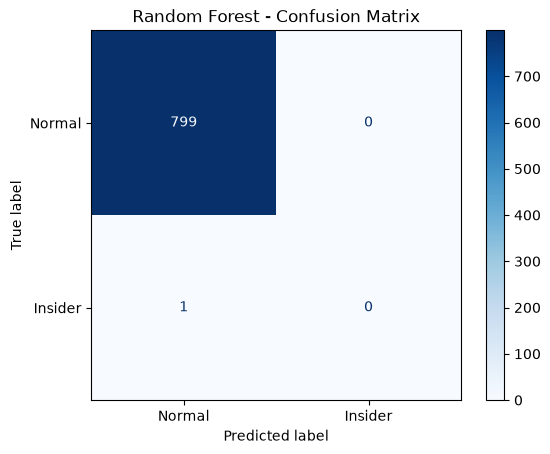

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Insider"]
)

disp.plot(cmap="Blues")

plt.title("Random Forest - Confusion Matrix")

plt.show()

# Classification Report

A detailed classification report shows precision, recall and F1-Score for every class.

In [45]:
print(
    classification_report(
        y_test,
        predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       799
           1       0.00      0.00      0.00         1

    accuracy                           1.00       800
   macro avg       0.50      0.50      0.50       800
weighted avg       1.00      1.00      1.00       800



# Part H - SHAP (Shapley Additive Explanations)

SHAP (SHapley Additive exPlanations) explains individual predictions by computing the contribution of each feature based on cooperative game theory.

Unlike feature importance and permutation importance, SHAP provides:

- Global explanations: which features drive the model overall.
- Local explanations: why a specific employee received a particular prediction.

In this section, a TreeExplainer is used to compute SHAP values for every test employee.

The insider-threat (positive) class is used for the analysis.

In [46]:
# Compute SHAP Values

print("=" * 70)
print("COMPUTING SHAP VALUES (TREE EXPLAINER)")
print("=" * 70)

import shap

explainer = shap.TreeExplainer(random_forest)

shap_values = explainer.shap_values(X_test)

shap_values = shap_values[:, :, 1]

print()
print("SHAP Values Shape :", shap_values.shape)
print("Expected Value :", round(explainer.expected_value[1], 4))

COMPUTING SHAP VALUES (TREE EXPLAINER)



SHAP Values Shape : (800, 47)
Expected Value : 0.4998


# SHAP Summary Plot (Beeswarm)

The beeswarm plot shows how each feature contributes to the insider-threat prediction.

- Each dot represents one employee.
- The horizontal position shows the SHAP value (positive = increases insider probability).
- The colour shows the feature value (high = red, low = blue).

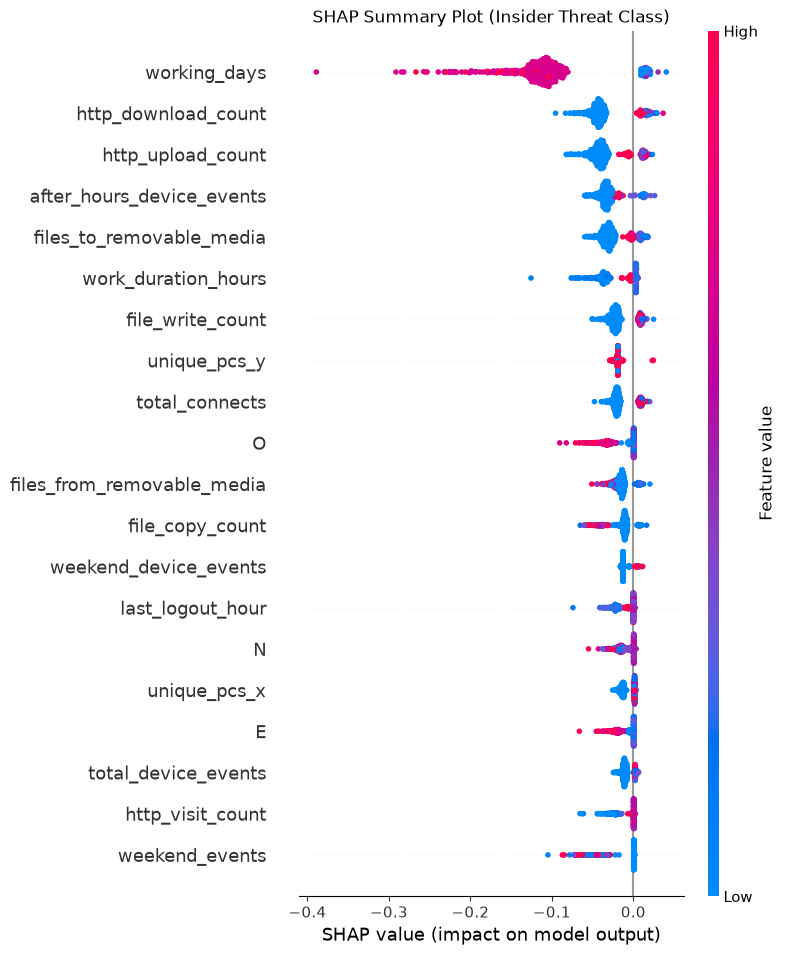

In [47]:
# SHAP Summary Plot (Beeswarm)

plt.figure(figsize=(12, 10))

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns,
    show=False
)

plt.title("SHAP Summary Plot (Insider Threat Class)")

plt.show()

# SHAP Global Feature Importance (Bar Plot)

The bar plot shows the mean absolute SHAP value for each feature.

Features with larger bars have a greater average impact on the model's predictions.

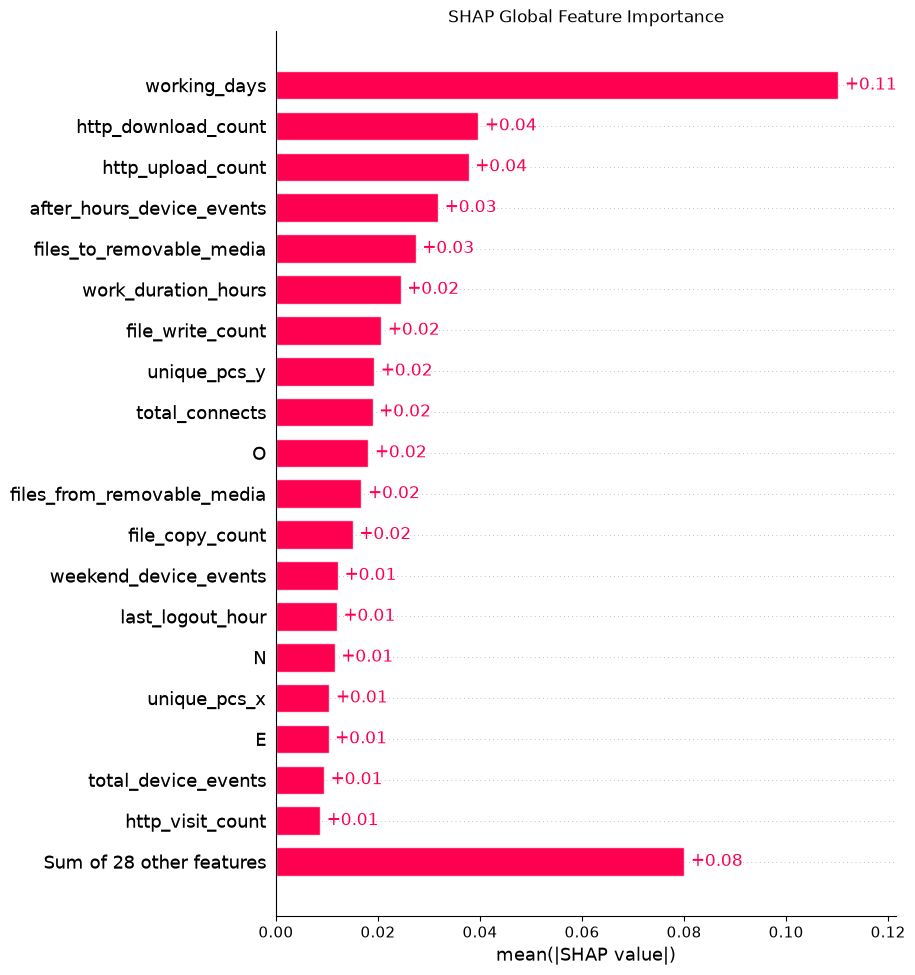

In [48]:
# SHAP Global Feature Importance (Bar Plot)

plt.figure(figsize=(12, 8))

shap.plots.bar(
    shap.Explanation(
        values=shap_values,
        base_values=explainer.expected_value[1],
        data=X_test.values,
        feature_names=X_test.columns
    ),
    max_display=20,
    show=False
)

plt.title("SHAP Global Feature Importance")

plt.show()

# Top 10 SHAP Features

The mean absolute SHAP value quantifies how strongly each feature influences predictions on average.

In [49]:
# Top 10 SHAP Features

shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean |SHAP|": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "Mean |SHAP|",
    ascending=False
)

print("=" * 70)
print("TOP 10 SHAP FEATURES")
print("=" * 70)

display(
    shap_importance.head(10)
)

shap_importance.to_csv(
    "../DATA/processed/shap_importance.csv",
    index=False
)

print()
print("SHAP Importance Saved Successfully")

TOP 10 SHAP FEATURES


,Feature,Mean |SHAP|
6,working_days,0.110224
36,http_download_count,0.039657
37,http_upload_count,0.037763
14,after_hours_device_events,0.031779
28,files_to_removable_media,0.027391
10,work_duration_hours,0.024439
26,file_write_count,0.020643
31,unique_pcs_y,0.019253
12,total_connects,0.018927
42,O,0.018094



SHAP Importance Saved Successfully


# Local Explanation - Highest Risk Employee

The waterfall plot explains the prediction for the employee with the highest insider probability.

Each bar shows how a feature increased (red) or decreased (blue) the probability of being an insider.

The final value represents the model's predicted insider probability.

Employee Index : 350
Insider Probability : 0.19


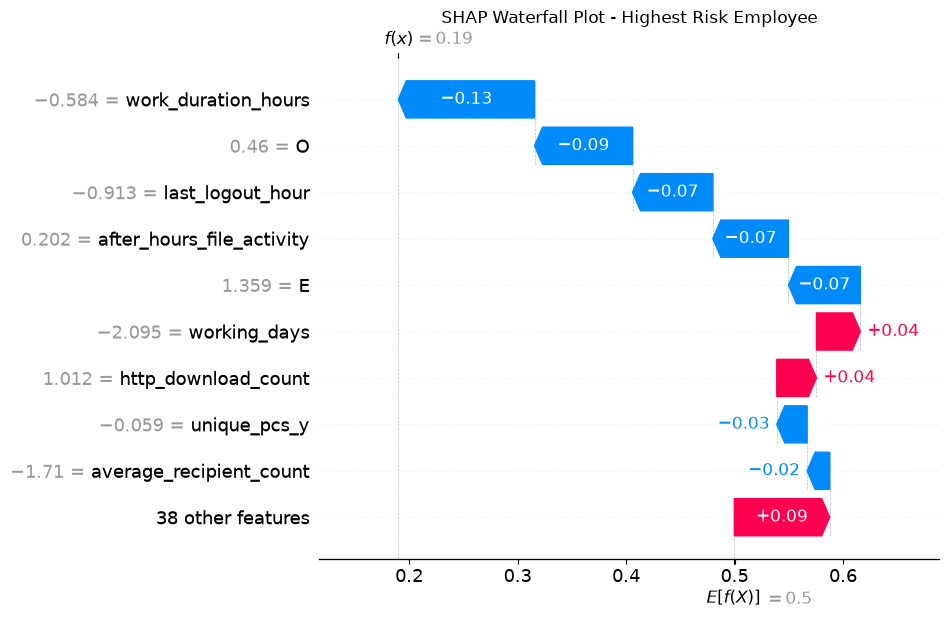

In [50]:
# Waterfall Plot - Highest Risk Employee

highest_risk_idx = prediction_df[
    "Insider Probability"
].idxmax()

print(
    "Employee Index :",
    highest_risk_idx
)

print(
    "Insider Probability :",
    round(
        prediction_df.loc[
            highest_risk_idx,
            "Insider Probability"
        ],
        4
    )
)

plt.figure(figsize=(12, 5))

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[highest_risk_idx],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[highest_risk_idx].values,
        feature_names=X_test.columns
    ),
    show=False
)

plt.title("SHAP Waterfall Plot - Highest Risk Employee")

plt.show()

# SHAP Interpretation

The SHAP analysis supports the earlier explainability findings:

- Working patterns (working_days, after-hours activity) and internet activity (HTTP downloads/uploads) are the strongest drivers of insider-threat predictions.
- File operations and removable media usage push predictions towards the insider class.
- For the highest-risk employee, the waterfall plot shows which behaviours contributed most to their insider probability.

SHAP therefore complements the global analyses by providing transparent, individual-level explanations for each employee.

# Conclusion

The Random Forest model is highly accurate on this dataset, but it fails to detect the rare insider-threat class.

This confirms that:

- Accuracy alone is misleading for highly imbalanced cybersecurity datasets.
- Global explainability (prediction distribution, confusion matrix, permutation importance) shows the model relies on normal-user patterns.
- A reliable insider threat system must combine classification with anomaly detection and SHAP-style local explanations for individual flagged users.